# EDA: dev_set_final.csv

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
pd.set_option('display.max_colwidth', 80)


In [2]:
df = pd.read_csv('../data/dev_set_final.csv')
df.shape

(94488, 3)

In [3]:
df.head()

,context,first letter,answer
0,south korea and the united states on monday warned north korea to avoid prov...,d,day
1,"after agreeing to drastically cut its car import duties , taiwan on thursday...",t,the
2,three soldiers were injured in a bombing ambush launched by suspect thai sou...,m,morning
3,an aviation official says a yemeni investigation team has found that a yemen...,w,was
4,"the movement for democracy in liberia ( model ) , the second largest rebel g...",t,to


## Basic info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94488 entries, 0 to 94487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   context       94488 non-null  str  
 1   first letter  94488 non-null  str  
 2   answer        94488 non-null  str  
dtypes: str(3)
memory usage: 14.9 MB


In [5]:
df.isna().sum()

context         0
first letter    0
answer          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5224)

## Context length distribution (words / chars)

In [7]:
df['ctx_word_len'] = df['context'].str.split().str.len()
df['ctx_char_len'] = df['context'].str.len()
df[['ctx_word_len','ctx_char_len']].describe()

,ctx_word_len,ctx_char_len
count,94488.000000,94488.000000
mean,24.571374,136.345758
std,6.591710,36.124628
min,7.000000,27.000000
25%,20.000000,113.000000
50%,24.000000,136.000000
75%,29.000000,158.000000
max,71.000000,359.000000


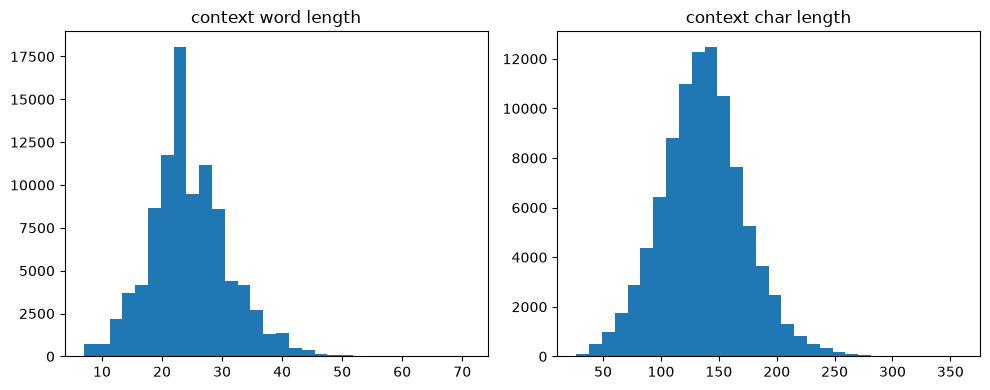

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(df['ctx_word_len'], bins=30); ax[0].set_title('context word length')
ax[1].hist(df['ctx_char_len'], bins=30); ax[1].set_title('context char length')
plt.tight_layout(); plt.show()

## First letter distribution

In [9]:
df['first letter'].value_counts()

first letter
t    12934
a     9921
s     6751
o     5609
i     5253
,     4722
c     4638
f     4016
p     3899
w     3616
b     3465
m     2995
h     2790
d     2641
r     2591
-     2256
1     2090
e     2067
l     1945
n     1780
g     1374
'     1246
u     1208
.      806
k      562
y      559
v      527
j      519
"      465
(      286
)      220
q      202
$      101
z       91
_       90
[       63
]       61
:       48
x       42
\       14
/        7
!        6
&        5
?        3
;        2
@        1
%        1
Name: count, dtype: int64

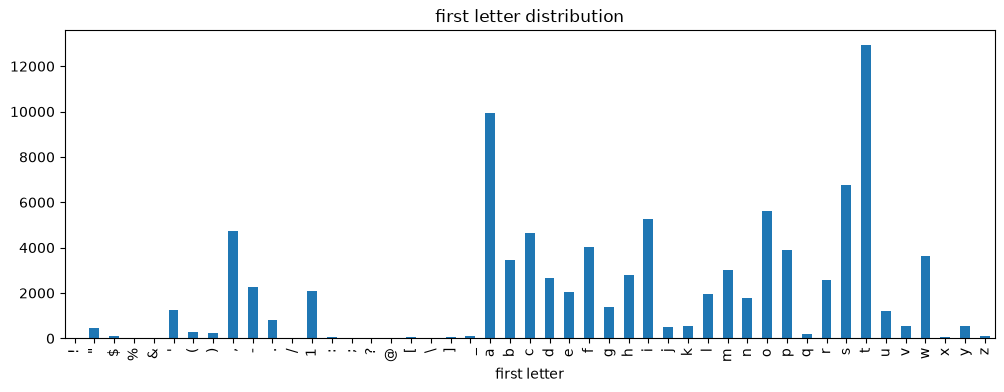

In [10]:
df['first letter'].value_counts().sort_index().plot.bar(figsize=(12,4), title='first letter distribution'); plt.show()

## Answer category: word / number / symbol

In [11]:

def categorize(tok):
    if re.fullmatch(r"[0-9]+", tok):
        return "number"
    if re.fullmatch(r"[a-z']+", tok, re.IGNORECASE):
        return "word"
    return "symbol"


In [12]:
df['answer_cat'] = df['answer'].astype(str).apply(categorize)
df['answer_cat'].value_counts()

answer_cat
word      83228
symbol     9237
number     2023
Name: count, dtype: int64

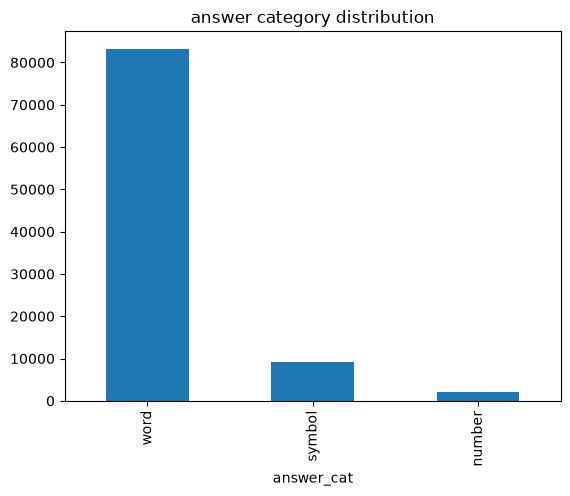

In [13]:
df['answer_cat'].value_counts().plot.bar(title='answer category distribution'); plt.show()

## How deterministic are symbol / number answers from first letter alone?
For each `first letter` value in the symbol/number category, does it always map to the same
`answer`? If so, that first letter alone determines the prediction -- no context needed.

In [14]:
for cat in ['symbol', 'number']:
    sub = df[df['answer_cat'] == cat]
    per_letter = sub.groupby('first letter')['answer'].nunique().sort_values(ascending=False)
    n_deterministic = (per_letter == 1).sum()
    print(f"--- {cat} ({len(sub)} rows, {len(per_letter)} distinct first letters) ---")
    print(f"deterministic (1 unique answer): {n_deterministic}/{len(per_letter)} first letters")
    ambiguous = per_letter[per_letter > 1]
    if len(ambiguous):
        print("ambiguous first letters (need context, not just the letter):")
        print(ambiguous)
    print()

--- symbol (9237 rows, 27 distinct first letters) ---
deterministic (1 unique answer): 24/27 first letters
ambiguous first letters (need context, not just the letter):
first letter
1    15
e     2
u     2
Name: answer, dtype: int64

--- number (2023 rows, 1 distinct first letters) ---
deterministic (1 unique answer): 0/1 first letters
ambiguous first letters (need context, not just the letter):
first letter
1    4
Name: answer, dtype: int64



In [15]:
# Row-level accuracy of a "majority answer per first letter" rule -- if a first letter isn't
# perfectly deterministic, how good is just guessing its most common answer anyway?
for cat in ['symbol', 'number']:
    sub = df[df['answer_cat'] == cat]
    majority = sub.groupby('first letter')['answer'].agg(lambda s: s.value_counts().idxmax())
    pred = sub['first letter'].map(majority)
    acc = (pred == sub['answer']).mean()
    print(f"{cat}: majority-per-first-letter accuracy = {acc:.4f} ({(pred == sub['answer']).sum()}/{len(sub)})")

symbol: majority-per-first-letter accuracy = 0.9958 (9198/9237)
number: majority-per-first-letter accuracy = 0.3964 (802/2023)


## Answer length distribution

In [16]:
df['answer_len'] = df['answer'].astype(str).str.len()
df['answer_len'].describe()

count    94488.000000
mean         4.428721
std          2.779209
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         18.000000
Name: answer_len, dtype: float64

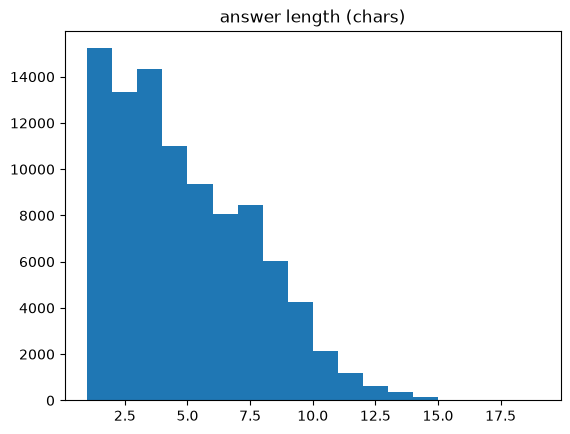

In [17]:
plt.hist(df['answer_len'], bins=range(1, df['answer_len'].max()+2)); plt.title('answer length (chars)'); plt.show()

## Answer first-letter consistency check

In [18]:
mismatch = df[df['answer'].astype(str).str[0] != df['first letter'].astype(str)]
len(mismatch), mismatch.head()

(0,
 Empty DataFrame
 Columns: [context, first letter, answer, ctx_word_len, ctx_char_len, answer_cat, answer_len]
 Index: [])

## Token list for dev (unique answers)

In [19]:
answer_counts = df['answer'].value_counts()
print('unique answers:', answer_counts.shape[0])
answer_counts.head(30)

unique answers: 10308


answer
the      5602
,        4722
of       2770
to       2729
a        2548
in       2358
-        2256
and      1757
'        1246
s        1238
for       960
on        892
.         806
11        802
at        711
that      626
1         621
from      516
with      506
by        485
"         465
an        427
his       424
as        423
111       372
its       336
was       310
after     292
(         286
year      282
Name: count, dtype: int64

In [20]:
answer_counts.tail(30)

answer
rekindled         1
lectures          1
blaine            1
prehistoric       1
secs              1
billboards        1
negotiators       1
mediate           1
freddie           1
pradesh           1
shortens          1
bhp               1
restricts         1
reactivate        1
ejected           1
acknowledgment    1
southernmost      1
astrid            1
comprising        1
sitting           1
stretched         1
eat               1
111s              1
vials             1
porto             1
yuans             1
integrity         1
survivors         1
abused            1
excellent         1
Name: count, dtype: int64

In [21]:
token_list_dev = sorted(answer_counts.index.tolist())
len(token_list_dev)

10308

In [22]:
import json
with open('../data/dev_token_list.json','w') as f:
    json.dump(token_list_dev, f)
print('saved dev_token_list.json')

saved dev_token_list.json


## Context vocabulary (unique tokens appearing in context)

In [23]:
ctx_tokens = pd.Series(' '.join(df['context']).split())
ctx_vocab = ctx_tokens.value_counts()
print('unique context tokens:', ctx_vocab.shape[0])
ctx_vocab.head(30)

unique context tokens: 44321


the      115817
,         73455
a         65411
of        61900
to        56860
in        50089
and       35999
-         33781
s         33584
'         32423
on        30168
.         29325
for       20489
11        19922
1         17997
that      15928
with      12914
at        11384
an        11153
as        10974
has       10396
[UNK]     10206
"         10199
111       10088
by        10050
from       9747
(          8911
was        8898
said       8852
will       8334
Name: count, dtype: int64